### 1.	Load Data
	•	Read the CSV file into a Pandas DataFrame.
	•	Check for missing values and handle them appropriately (fill/replace/drop).

In [2]:
import numpy as np
import pandas as pd

df=pd.read_csv("sales_data.csv")
df.fillna(0,inplace=True)

,Date,Region,Product,Units_Sold,Revenue
0,2024-01,North,Laptop,152,252168
1,2024-01,North,Smartphone,398,594612
2,2024-01,North,Tablet,156,202020
3,2024-01,North,Headphones,238,296072
4,2024-01,North,Smartwatch,152,48792
...,...,...,...,...,...
235,2024-12,West,Laptop,153,247248
236,2024-12,West,Smartphone,348,154860
237,2024-12,West,Tablet,225,283950
238,2024-12,West,Headphones,219,209802


### 2.	Data Cleaning & Manipulation
	•	Convert the Date column to proper datetime format.
	•	Extract Year and Month as new columns.
	•	Add a new column Revenue_per_Unit = Revenue / Units_Sold.

In [3]:
df["Date"]=pd.to_datetime(df["Date"])
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Revenue_per_Unit"]=df["Revenue"]/df["Units_Sold"]
print(df)

          Date Region     Product  Units_Sold  Revenue  Year  Month  \
0   2024-01-01  North      Laptop         152   252168  2024      1   
1   2024-01-01  North  Smartphone         398   594612  2024      1   
2   2024-01-01  North      Tablet         156   202020  2024      1   
3   2024-01-01  North  Headphones         238   296072  2024      1   
4   2024-01-01  North  Smartwatch         152    48792  2024      1   
..         ...    ...         ...         ...      ...   ...    ...   
235 2024-12-01   West      Laptop         153   247248  2024     12   
236 2024-12-01   West  Smartphone         348   154860  2024     12   
237 2024-12-01   West      Tablet         225   283950  2024     12   
238 2024-12-01   West  Headphones         219   209802  2024     12   
239 2024-12-01   West  Smartwatch          75    84000  2024     12   

     Revenue_per_Unit  
0              1659.0  
1              1494.0  
2              1295.0  
3              1244.0  
4               321.0  
.. 

### 3.	Exploratory Analysis
	•	Find the top 3 products by total revenue.
	•	Calculate average monthly sales per region.
	•	Use groupby and agg to get total revenue and average units sold per product.

In [10]:
top_products=df.groupby("Product")["Revenue"].sum().head(3).sort_values(ascending=True)
avgsalreg=df.groupby(["Month","Region"])["Revenue"].mean().reset_index()
product_stats=df.groupby("Product").agg({
    "Revenue": "mean",
    "Units_Sold": "mean"
})

print(top_products)
print(avgsalreg)
print(product_stats)

Product
Headphones    13757810
Laptop        14464264
Smartphone    17045539
Name: Revenue, dtype: int64
    Month Region   Revenue
0       1   East  324119.8
1       1  North  278732.8
2       1  South  177869.8
3       1   West  303574.8
4       2   East  338609.2
5       2  North  391597.0
6       2  South  261370.2
7       2   West  358984.4
8       3   East  256373.6
9       3  North  440679.0
10      3  South  381133.8
11      3   West  246923.4
12      4   East  296517.0
13      4  North  253937.4
14      4  South  217356.8
15      4   West  332519.0
16      5   East  297760.2
17      5  North  313345.2
18      5  South  320531.2
19      5   West  309074.8
20      6   East  421058.4
21      6  North  176566.6
22      6  South  350842.8
23      6   West  409638.6
24      7   East  305141.6
25      7  North  431458.0
26      7  South  520041.8
27      7   West  377254.4
28      8   East  442612.4
29      8  North  316773.8
30      8  South  240412.8
31      8   West  441056.0
32  

### 4.	NumPy Integration
	•	Use NumPy functions to calculate:
	•	Overall mean, median, and standard deviation of Revenue.
	•	A NumPy array of Revenue_per_Unit for correlation analysis.

In [11]:
mean_rev=np.mean(df["Revenue"])
median_rev=np.median(df["Revenue"])
std_rev=np.std(df["Revenue"])

rev_per_unit_array=np.array(df["Revenue_per_Unit"])
correlation=np.corrcoef(df["Units_Sold"],rev_per_unit_array)
print(correlation)

[[1.         0.03635231]
 [0.03635231 1.        ]]


### 5.	Visualization (Matplotlib/Seaborn)
	•	Plot a bar chart of total revenue per region.
	•	Create a line plot showing monthly revenue trends.
	•	Plot a scatter plot of Units_Sold vs. Revenue, colored by Region.

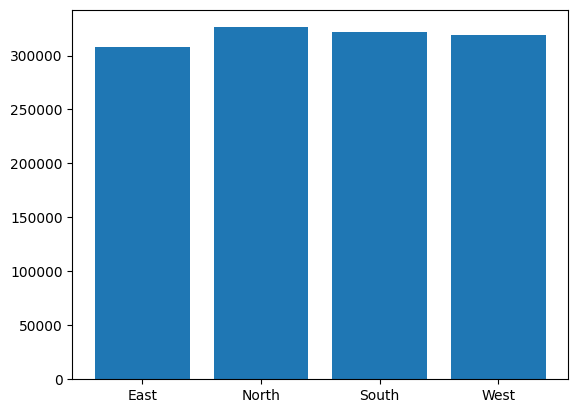

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
x=df.groupby("Region")["Revenue"].mean().reset_index()
plt.bar(x["Region"],x["Revenue"])
plt.show()

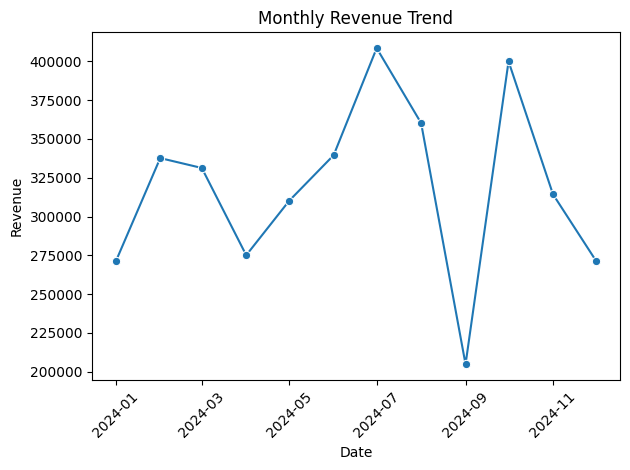

In [7]:
mon_rev_tre=df.groupby("Date")["Revenue"].mean().reset_index()
sns.lineplot(x="Date",y="Revenue",data=mon_rev_tre,marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

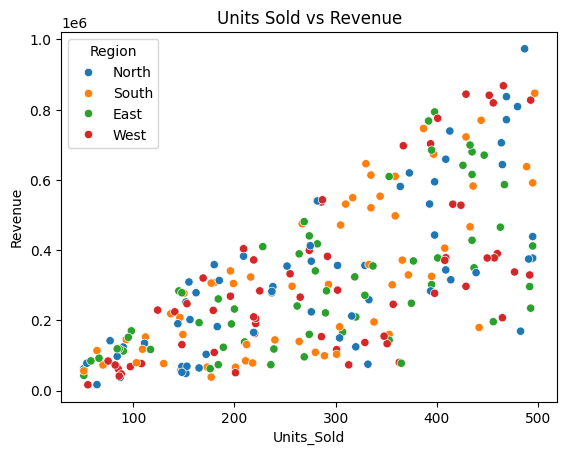

In [8]:
sns.scatterplot(x="Units_Sold",y="Revenue",hue="Region",data=df)
plt.title("Units Sold vs Revenue")
plt.show()